# nor + ext

In [29]:
from graphviz import Digraph

dot = Digraph(comment='The Round Table')
dot.node('A', 'King Arthur')
dot.node('B', 'Sir Bedevere the Wise')
dot.node('L', 'Sir Lancelot the Brave')
dot.edges(['AB', 'AL'])
dot.render('round-table.gv', view=True)

ModuleNotFoundError: No module named 'graphviz'

In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2016]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdem = rf'{grid_folder}\statistics\SDEM_all_params.xlsx'
    best_df_sdem = pd.read_excel(best_params_file_sdem)

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    print(target_folder)

    for target in target_folder[1:]:

        # 先收集 EXT 和 NOR 的预测数据
        ext_targets = [t for t in target_folder if ('ext' in t.lower()) or ('nor' in t.lower())]
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- EXT + NOR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            for target in ext_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])
                model = GradientBoostingRegressor(**params_gbdt).fit(X_train, y_train)
                # ----------- PDP 计算部分 -----------
                pdp_result = partial_dependence(
                    model,
                    X_test,
                    [feature],
                    grid_resolution=100,
                    kind='average'
                )

                X_grid = pdp_result['values'][0]
                y_pdp_pred = pdp_result['average'][0] + y_test.mean()
                print(y_pdp_pred)

                # SDEM
                row_sdem = best_df_sdem[best_df_sdem['Target']==target].iloc[0]
                params_sdem = {
                    'CONSTANT': row_sdem['CONSTANT'],
                    'BCR': row_sdem['BCR'],
                    'BHV': row_sdem['BHV'],
                    'SVF': row_sdem['SVF'],
                    'NDVI': row_sdem['NDVI'],
                    'EV': row_sdem['EV'],
                    'WR': row_sdem['WR'],
                    'Dist_W': row_sdem['Dist_W'],
                    'Dist_P': row_sdem['Dist_P'],
                    'Dist_M': row_sdem['Dist_M'],
                    'W_BCR': row_sdem['W_BCR'],
                    'W_BHV': row_sdem['W_BHV'],
                    'W_SVF': row_sdem['W_SVF'],
                    'W_NDVI': row_sdem['W_NDVI'],
                    'W_EV': row_sdem['W_EV'],
                    'W_WR': row_sdem['W_WR'],
                    'lambda': row_sdem['lambda']
                }
                # SDEM 预测
                X_mean = gdf_clean[explanatory_vars].mean().to_dict()
                w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
                w.transform = 'r'
                WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values)
                WX_mean = pd.Series(WX.mean(axis=0), index=[f"W_{v}" for v in explanatory_vars_clean])
                y_sdem_pred = []
                for val in X_grid:
                    X_temp = X_mean.copy()
                    X_temp[feature] = val
                    WX_temp = WX_mean.copy()
                    if feature in explanatory_vars_clean:
                        WX_temp[feature] = pd.Series(val, index=[f"W_{feature}"])
                    all_vars = {'CONSTANT': 1.0, **X_temp, **WX_temp.to_dict()}
                    y_pred = 0
                    for var, coef in params_sdem.items():
                        if var != 'lambda':
                            y_pred += coef * all_vars.get(var, 0)
                    y_sdem_pred.append(y_pred)
                y_sdem_pred = np.array(y_sdem_pred)

                # 根据 EXT/NOR 指定颜色
                if 'ext' in target.lower():
                    color_gbdt = '#333333'  # 黑色
                    color_sdem = '#555555'  # 黑色虚线
                else:  # NOR
                    color_gbdt = '#0000ff'  # 蓝色
                    color_sdem = '#0000ff'  # 蓝色虚线

                # 命名规范映射
                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名
                # 绘图
                plt.plot(X_grid, y_pdp_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdem_pred, color=color_sdem, linestyle='--', linewidth=2, label=f'{label_name} SDEM')
            # 设置全局字体为 Times New Roman
            plt.rcParams["font.family"] = "Times New Roman"
            plt.xlabel(feature, fontsize=20)
            plt.ylabel('Temperature (℃)', fontsize=20)
            plt.grid(True)
            plt.legend()
            plt.ylim(20,55)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_ext_nor_{year}_comparison.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_ext_nor_{year}_comparison.png")

: 

: 

# hr

In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2016]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdem = rf'{grid_folder}\statistics\SDM_SDEM_all_params.xlsx'
    best_df_sdem = pd.read_excel(best_params_file_sdem)

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    print(target_folder)

    for target in target_folder[2:]:
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- EXT + NOR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            for target in hr_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])
                model = GradientBoostingRegressor(**params_gbdt).fit(X_train, y_train)
                # ----------- PDP 计算部分 -----------
                pdp_result = partial_dependence(
                    model,
                    X_test,
                    [feature],
                    grid_resolution=100,
                    kind='average'
                )

                X_grid = pdp_result['values'][0]
                y_pdp_pred = pdp_result['average'][0] + y_test.mean()
                print(y_pdp_pred)

                # SDEM
                row_sdem = best_df_sdem[best_df_sdem['Target']==target].iloc[0]
                params_sdem = {
                    'CONSTANT': row_sdem['CONSTANT'],
                    'BCR': row_sdem['BCR'],
                    'BHV': row_sdem['BHV'],
                    'SVF': row_sdem['SVF'],
                    'NDVI': row_sdem['NDVI'],
                    'EV': row_sdem['EV'],
                    'WR': row_sdem['WR'],
                    'Dist_W': row_sdem['Dist_W'],
                    'Dist_P': row_sdem['Dist_P'],
                    'Dist_M': row_sdem['Dist_M'],
                    'W_BCR': row_sdem['W_BCR'],
                    'W_BHV': row_sdem['W_BHV'],
                    'W_SVF': row_sdem['W_SVF'],
                    'W_NDVI': row_sdem['W_NDVI'],
                    'W_EV': row_sdem['W_EV'],
                    'W_WR': row_sdem['W_WR'],
                    'lambda': row_sdem['lambda']
                }
                # SDEM 预测
                X_mean = gdf_clean[explanatory_vars].mean().to_dict()
                w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
                w.transform = 'r'
                WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values)
                WX_mean = pd.Series(WX.mean(axis=0), index=[f"W_{v}" for v in explanatory_vars_clean])
                y_sdem_pred = []
                for val in X_grid:
                    X_temp = X_mean.copy()
                    X_temp[feature] = val
                    WX_temp = WX_mean.copy()
                    if feature in explanatory_vars_clean:
                        WX_temp[feature] = pd.Series(val, index=[f"W_{feature}"])
                    all_vars = {'CONSTANT': 1.0, **X_temp, **WX_temp.to_dict()}
                    y_pred = 0
                    for var, coef in params_sdem.items():
                        if var != 'lambda':
                            y_pred += coef * all_vars.get(var, 0)
                    y_sdem_pred.append(y_pred)
                y_sdem_pred = np.array(y_sdem_pred)


                color_gbdt = '#333333'  # 黑色
                color_sdem = '#555555'  # 黑色虚线

                # 命名规范映射
                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名
                # 绘图
                plt.plot(X_grid, y_pdp_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdem_pred, color=color_sdem, linestyle='--', linewidth=2, label=f'{label_name} SDEM')
            # 设置全局字体为 Times New Roman
            plt.rcParams["font.family"] = "Times New Roman"
            plt.xlabel(feature, fontsize=20)
            plt.ylabel('Temperature (℃)', fontsize=20)

            plt.grid(True)
            plt.legend()
            plt.ylim(-15,-1)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_hr_{year}_comparison.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_hr_{year}_comparison.png")

: 

: 

# try brute hr

In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP_brute'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2016]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdem = rf'{grid_folder}\statistics\SDEM_all_params.xlsx'
    best_df_sdem = pd.read_excel(best_params_file_sdem)

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    # print(target_folder)

    for target in target_folder[2:]:
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- EXT + NOR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            for target in hr_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])
                # X_test_min = X_test.min()
                # X_test_max = X_test.max()
                # print(f'{target}: min - {X_test_min}_ max - {X_test_max}')
                model = GradientBoostingRegressor(**params_gbdt).fit(X_train, y_train)
                # ----------- PDP 计算部分 -----------
                pdp_result = partial_dependence(
                    model,
                    X_test,
                    [feature],
                    method='brute',
                    grid_resolution=100,
                    kind='average'
                )

                X_grid = pdp_result['values'][0]
                print(X_grid.min())
                print(X_grid.max())
                y_pdp_pred = pdp_result['average'][0]# + y_test.mean()
                #print(y_pdp_pred)

                # SDEM
                row_sdem = best_df_sdem[best_df_sdem['Target']==target].iloc[0]
                params_sdem = {
                    'CONSTANT': row_sdem['CONSTANT'],
                    'BCR': row_sdem['BCR'],
                    'BHV': row_sdem['BHV'],
                    'SVF': row_sdem['SVF'],
                    'NDVI': row_sdem['NDVI'],
                    'EV': row_sdem['EV'],
                    'WR': row_sdem['WR'],
                    'Dist_W': row_sdem['Dist_W'],
                    'Dist_P': row_sdem['Dist_P'],
                    'Dist_M': row_sdem['Dist_M'],
                    'W_BCR': row_sdem['W_BCR'],
                    'W_BHV': row_sdem['W_BHV'],
                    'W_SVF': row_sdem['W_SVF'],
                    'W_NDVI': row_sdem['W_NDVI'],
                    'W_EV': row_sdem['W_EV'],
                    'W_WR': row_sdem['W_WR'],
                    'lambda': row_sdem['lambda']
                }
                # SDEM 预测
                X_mean = gdf_clean[explanatory_vars].mean().to_dict()
                w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
                w.transform = 'r'
                WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values)
                WX_mean = pd.Series(WX.mean(axis=0), index=[f"W_{v}" for v in explanatory_vars_clean])
                y_sdem_pred = []
                for val in X_grid:
                    X_temp = X_mean.copy()
                    X_temp[feature] = val
                    WX_temp = WX_mean.copy()
                    if feature in explanatory_vars_clean:
                        WX_temp[feature] = pd.Series(val, index=[f"W_{feature}"])
                    all_vars = {'CONSTANT': 1.0, **X_temp, **WX_temp.to_dict()}
                    y_pred = 0
                    for var, coef in params_sdem.items():
                        if var != 'lambda':
                            y_pred += coef * all_vars.get(var, 0)
                    y_sdem_pred.append(y_pred)
                y_sdem_pred = np.array(y_sdem_pred)


                color_gbdt = '#333333'  # 黑色
                color_sdem = '#555555'  # 黑色虚线

                # 命名规范映射
                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名
                # 绘图
                plt.plot(X_grid, y_pdp_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdem_pred, color=color_sdem, linestyle='--', linewidth=2, label=f'{label_name} SDEM')
            # 设置全局字体为 Times New Roman
            plt.rcParams["font.family"] = "Times New Roman"
            plt.xlabel(feature, fontsize=20)
            plt.ylabel('Temperature (℃)', fontsize=20)

            plt.grid(True)
            plt.legend()
            plt.ylim(-15,-1)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_hr_{year}_comparison.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_hr_{year}_comparison.png")

: 

: 

# try brute ext+nor

In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP_brute'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2016]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdem = rf'{grid_folder}\statistics\SDEM_all_params.xlsx'
    best_df_sdem = pd.read_excel(best_params_file_sdem)

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    print(target_folder)

    for target in target_folder[1:]:

        # 先收集 EXT 和 NOR 的预测数据
        ext_targets = [t for t in target_folder if ('ext' in t.lower()) or ('nor' in t.lower())]
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- EXT + NOR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            for target in ext_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])
                model = GradientBoostingRegressor(**params_gbdt).fit(X_train, y_train)
                # ----------- PDP 计算部分 -----------
                pdp_result = partial_dependence(
                    model,
                    X_test,
                    [feature],
                    method = 'brute',
                    grid_resolution=100,
                    kind='average'
                )

                X_grid = pdp_result['values'][0]
                y_pdp_pred = pdp_result['average'][0]
                print(y_pdp_pred)

                # SDEM
                row_sdem = best_df_sdem[best_df_sdem['Target']==target].iloc[0]
                params_sdem = {
                    'CONSTANT': row_sdem['CONSTANT'],
                    'BCR': row_sdem['BCR'],
                    'BHV': row_sdem['BHV'],
                    'SVF': row_sdem['SVF'],
                    'NDVI': row_sdem['NDVI'],
                    'EV': row_sdem['EV'],
                    'WR': row_sdem['WR'],
                    'Dist_W': row_sdem['Dist_W'],
                    'Dist_P': row_sdem['Dist_P'],
                    'Dist_M': row_sdem['Dist_M'],
                    'W_BCR': row_sdem['W_BCR'],
                    'W_BHV': row_sdem['W_BHV'],
                    'W_SVF': row_sdem['W_SVF'],
                    'W_NDVI': row_sdem['W_NDVI'],
                    'W_EV': row_sdem['W_EV'],
                    'W_WR': row_sdem['W_WR'],
                    'lambda': row_sdem['lambda']
                }
                # SDEM 预测
                X_mean = gdf_clean[explanatory_vars].mean().to_dict()
                w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
                w.transform = 'r'
                WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values)
                WX_mean = pd.Series(WX.mean(axis=0), index=[f"W_{v}" for v in explanatory_vars_clean])
                y_sdem_pred = []
                for val in X_grid:
                    X_temp = X_mean.copy()
                    X_temp[feature] = val
                    WX_temp = WX_mean.copy()
                    if feature in explanatory_vars_clean:
                        WX_temp[feature] = pd.Series(val, index=[f"W_{feature}"])
                    all_vars = {'CONSTANT': 1.0, **X_temp, **WX_temp.to_dict()}
                    y_pred = 0
                    for var, coef in params_sdem.items():
                        if var != 'lambda':
                            y_pred += coef * all_vars.get(var, 0)
                    y_sdem_pred.append(y_pred)
                y_sdem_pred = np.array(y_sdem_pred)

                # 根据 EXT/NOR 指定颜色
                if 'ext' in target.lower():
                    color_gbdt = '#333333'  # 黑色
                    color_sdem = '#555555'  # 黑色虚线
                else:  # NOR
                    color_gbdt = '#0000ff'  # 蓝色
                    color_sdem = '#0000ff'  # 蓝色虚线

                # 命名规范映射
                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名
                # 绘图
                plt.plot(X_grid, y_pdp_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdem_pred, color=color_sdem, linestyle='--', linewidth=2, label=f'{label_name} SDEM')
            # 设置全局字体为 Times New Roman
            plt.rcParams["font.family"] = "Times New Roman"
            plt.xlabel(feature, fontsize=20)
            plt.ylabel('Temperature (℃)', fontsize=20)
            plt.grid(True)
            plt.legend()
            plt.ylim(20,55)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_ext_nor_{year}_comparison.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_ext_nor_{year}_comparison.png")

: 

: 

# feature importance

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import hsv_to_rgb

# 设置全局字体为 Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# 读数据
grid_folder = r'E:\seoul\480_based'
path = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
df = pd.read_excel(path)

# pivot：每行一个 Target，每列一个 Feature
pivot = df.pivot_table(index='Target', columns='Feature', 
                       values='FeatureImportance_TrainModel', aggfunc='sum').fillna(0)

year = 2016
# 手动调整 Target 的行顺序
row_order = [f'hr_{year}', f'ext_{year}',f'nor_{year}']
pivot = pivot.reindex(row_order)

# 指定 Feature 顺序
explanatory_vars_gbdt = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 
                         'Dist_W', 'Dist_P', 'Dist_M', 'X', 'Y']


# 四组特征
groups = {
    'group1': ['BCR', 'BHV', 'SVF'],          # 湖蓝系
    'group2': ['NDVI', 'EV', 'WR'],           # 藏蓝系
    'group3': ['Dist_W', 'Dist_P', 'Dist_M'], # 棕色系
    'group4': ['X', 'Y']                      # 墨绿色系
}

base_colors = {
    'group4': np.array([0.4, 0.7, 0.9]),   # 柔和湖蓝
    'group1': np.array([0.2, 0.4, 0.7]),   # 深藏蓝
    'group2': np.array([0.35, 0.55, 0.4]), # 墨绿色
    'group3': np.array([0.7, 0.55, 0.35])# 高级咖啡棕}
 } 
# 生成组内渐变色（浅→深）
def generate_gradient_colors(features, base_rgb):
    n = len(features)
    colors = []
    for i in range(n):
        factor = 0.85 + 0.15*(i/(n-1))  # 浅→深
        colors.append(base_rgb * factor)
    return dict(zip(features, colors))

color_map = {}
for gname, feats in groups.items():
    color_map.update(generate_gradient_colors(feats, base_colors[gname]))

# 绘图
fig, ax = plt.subplots(figsize=(10, max(3, 0.8 * len(pivot))))
bottom = np.zeros(len(pivot))
# 绘图前设置 X 轴范围和刻度
ax.set_xlim(-0.02, 1.02)  # 超过 1 点点空间

# 设置 X 轴刻度为百分比
ax.set_xticks(np.linspace(0, 1, 11))  # 0,0.1,...,1
ax.set_xticklabels([f"{int(x*100)}%" for x in np.linspace(0, 1, 11)])

for feature in explanatory_vars_gbdt:
    vals = pivot[feature].values
    ax.barh(pivot.index, vals, left=bottom, color=color_map[feature], edgecolor='white')
    for i, val in enumerate(vals):
        txt = ax.text(
            bottom[i] + val/2, i, f"{val*100:.1f}", 
            va='center', ha='center', fontsize=10, color="white"
        )
        # 给文字加描边
        txt.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='#555555'),  # 描边颜色
            path_effects.Normal()  # 正常文字显示
        ])
    bottom += vals

# legend
handles = [plt.Rectangle((0,0),1,1,color=color_map[feature]) for feature in explanatory_vars_gbdt]
ax.legend(handles, explanatory_vars_gbdt, bbox_to_anchor=(1.02, 1.2), loc='upper left', title='Feature', frameon=False)

ax.set_xlabel("Percentage")

plt.tight_layout()
# 保存到本地（示例）
out_file = r"E:\seoul\480_based\Machine Learning\2016_final_GBDT_feature_importance_stacked.png"
fig.savefig(out_file, dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()
print("Saved to:", out_file)

: 

: 

In [ ]:
import pandas as pd
grid_folder = r'E:\seoul\480_based'
# 读取最佳参数
best_params_file_gbdt = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
best_df_gbdt = pd.read_excel(best_params_file_gbdt)
best_params_file_sdm = rf'{grid_folder}\statistics\SDM_SDEM_all_params.xlsx'
best_df_sdm = pd.read_excel(best_params_file_sdm)
best_df_sdm = best_df_sdm[best_df_sdm['Model']=='SDM']

: 

: 

# hr self

In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2016]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdem = rf'{grid_folder}\statistics\SDM_SDEM_all_params.xlsx'
    best_df_sdem = pd.read_excel(best_params_file_sdem)
    best_df_sdem = best_df_sdem[best_df_sdem['Model']=='SDEM']

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    # print(target_folder)

    for target in target_folder[2:]:
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- EXT + NOR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            for target in hr_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])

                # ----------- PDP 计算部分 -----------
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns)
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)

                # SDEM
                row_sdem = best_df_sdem[best_df_sdem['Target']==target].iloc[0]
                params_sdem = {
                    'CONSTANT': row_sdem['CONSTANT'],
                    'BCR': row_sdem['BCR'],
                    'BHV': row_sdem['BHV'],
                    'SVF': row_sdem['SVF'],
                    'NDVI': row_sdem['NDVI'],
                    'EV': row_sdem['EV'],
                    'WR': row_sdem['WR'],
                    'Dist_W': row_sdem['Dist_W'],
                    'Dist_P': row_sdem['Dist_P'],
                    'Dist_M': row_sdem['Dist_M'],
                    'W_BCR': row_sdem['W_BCR'],
                    'W_BHV': row_sdem['W_BHV'],
                    'W_SVF': row_sdem['W_SVF'],
                    'W_NDVI': row_sdem['W_NDVI'],
                    'W_EV': row_sdem['W_EV'],
                    'W_WR': row_sdem['W_WR'],
                    'lambda': row_sdem['lambda']
                }

                # SDEM 预测
                X_mean = gdf_clean[explanatory_vars].mean().to_dict()
                w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
                w.transform = 'r'
                WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values)
                WX_mean = pd.Series(WX.mean(axis=0), index=[f"W_{v}" for v in explanatory_vars_clean])
                # y_base：平均值预测
                all_vars_base = {'CONSTANT': 1.0, **X_mean, **WX_mean.to_dict()}
                y_base = sum(params_sdem[var] * all_vars_base.get(var, 0) for var in params_sdem if var != 'lambda')
                y_sdem_pred = []
                for val in X_grid:
                    X_temp = X_mean.copy()
                    X_temp[feature] = val
                    WX_temp = WX_mean.copy()
                    if feature in explanatory_vars_clean:
                        WX_temp[feature] = pd.Series(val, index=[f"W_{feature}"])

                    all_vars = {'CONSTANT': 1.0, **X_temp, **WX_temp.to_dict()}
                    y_pred = 0
                    for var, coef in params_sdem.items():
                        if var != 'lambda':
                            y_pred += coef * all_vars.get(var, 0)
                    y_sdem_pred.append(y_pred)
                    
                y_sdem_pred = np.array(y_sdem_pred)


                color_gbdt = '#333333'  # 黑色
                color_sdm = '#555555'  # 黑色虚线

                # 命名规范映射
                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名


                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_base, color=color_gbdt, linewidth=2, label=f'{label_name} mean based')
                plt.plot(X_grid, y_sdem_pred, color=color_sdm, linestyle='--', linewidth=2, label=f'{label_name} SDEM')

            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())

            # 设置全局字体为 Times New Roman
            plt.rcParams["font.family"] = "Times New Roman"

            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.margins(x=0)  # 去掉x方向留白
             
             
             
            plt.ylim(-15,-1)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_hr_{year}_comparison.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_hr_{year}_comparison.png")

c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved BCR_hr_2016_comparison.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved BHV_hr_2016_comparison.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


...

('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved Dist_P_hr_2016_comparison.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved Dist_M_hr_2016_comparison.png


: 

: 

# hr sdm

In [7]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2016]


for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdm = rf'{grid_folder}\statistics\SDM_all_params_480m_NOW.xlsx'
    best_df_sdm = pd.read_excel(best_params_file_sdm)
    best_df_sdm = best_df_sdm[best_df_sdm['Model']=='SDM']
    effects_file = r"E:\seoul\480_based\statistics\SDM_effects.xlsx"

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    # print(target_folder)

    for target in target_folder[2:]:
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- HR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            # 设置全局字体为 Times New Roman
            plt.rcParams["font.family"] = "Times New Roman"
            for target in hr_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]

                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])

                # ----------- PDP 计算部分 -----------
                # GBDT
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns) # type: ignore
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)

                # SDM
                row_sdm = best_df_sdm[best_df_sdm['Target']==target].iloc[0]
                rho_col = [c for c in row_sdm.index if c.lower() == f"w_{target.lower()}"] #rho_col = ['W_hr_2016']
                rho = float(row_sdm[rho_col[0]]) 

                params_sdm = {
                    'CONSTANT': row_sdm['CONSTANT'],
                    'Wy': rho,
                    'BCR': row_sdm['BCR'],
                    'BHV': row_sdm['BHV'],
                    'SVF': row_sdm['SVF'],
                    'NDVI': row_sdm['NDVI'],
                    'EV': row_sdm['EV'],
                    'WR': row_sdm['WR'],
                    'Dist_W': row_sdm['Dist_W'],
                    'Dist_P': row_sdm['Dist_P'],
                    'Dist_M': row_sdm['Dist_M'],
                    'W_BCR': row_sdm['W_BCR'],
                    'W_BHV': row_sdm['W_BHV'],
                    'W_SVF': row_sdm['W_SVF'],
                    'W_NDVI': row_sdm['W_NDVI'],
                    'W_EV': row_sdm['W_EV'],
                    'W_WR': row_sdm['W_WR']
                }

                # SDM 预测
                data = gdf_clean[explanatory_vars + [target]].dropna()
                data_gdf = gdf_clean.loc[data.index].reset_index(drop=True)

                threshold = 1000
                w = DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'  # 行标准化
                
                # 找孤岛
                row_sums = w.full()[0].sum(axis=1)
                islands = np.where(row_sums == 0)[0]

                # 删除孤岛
                data_gdf = data_gdf.drop(data_gdf.index[islands]).reset_index(drop=True)
                data = data_gdf[explanatory_vars + [target]]

                # 再生成 W
                w = DistanceBand.from_dataframe(data_gdf, threshold=1000, binary=False)
                w.transform = 'r'
                W = np.array(w.full()[0])  # 稠密矩阵

                constant = np.array([params_sdm.get('CONSTANT', 0)]) 
                beta = np.array([params_sdm.get(var, 0) for var in explanatory_vars])   # (9,)
                theta = np.array([params_sdm.get(f"W_{var}", 0) for var in explanatory_vars_clean])  # (6,)
                rho = params_sdm.get("Wy", 0)

                X_main = data[explanatory_vars].values
                WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)

                # SDM 计算
                I = np.eye(len(X_main))
                A_inv = np.linalg.inv(I - rho * W)
                X_all = np.hstack([np.ones((len(data), 1)), X_main, WX_clean])
                beta_all = np.array([row_sdm[var] for var in ['CONSTANT'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars_clean]], dtype=float)
                clean_col_indices = [explanatory_vars.index(c) for c in explanatory_vars_clean]  # len=6
                y_sdm_pred_list = []

                for val in X_grid:
                    # X_temp = X_main.copy()
                    # feature_idx = explanatory_vars.index(feature)
                    # X_temp[:, feature_idx] = val

                    # WX_temp = WX_clean.copy()
                    # if feature in explanatory_vars_clean:
                    #     m = clean_col_indices.index(explanatory_vars.index(feature))
                    #     WX_temp[:, m] = lag_spatial(w, X_temp[:, feature_idx].reshape(-1, 1)).flatten()
                    #     # WX_temp[:, m] = X_temp[:, feature_idx].reshape(-1, 1).flatten()

                    # X_all_temp = np.hstack([np.ones((len(data), 1)), X_temp, WX_temp])

                    # y_temp = A_inv @ (X_all_temp @ beta_all)
                    # y_sdm_pred_list.append(y_temp.mean())

                    df_effects = pd.read_excel(effects_file, sheet_name=target)

                    TE_total = df_effects.loc[df_effects['Variable'] == feature, 'Total'].values[0]

                    y_base_mean = data[target].mean()
                    feature_mean = data[feature].mean()

                    # PDP 自变量轴
                    X_grid = np.linspace(data[feature].min(), data[feature].max(), 100)

                    # SDM PDP：使用 total effect
                    y_sdm_pred_list = y_base_mean + TE_total * (X_grid - feature_mean)

                # 转为 numpy 数组
                y_sdm_pred_array = np.array(y_sdm_pred_list)
                
                color_gbdt = '#333333'  # 黑色
                color_sdm = '#555555'  # 黑色虚线
                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名


                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdm_pred_array, color=color_sdm, linestyle='--', linewidth=2, label=f'{label_name} SDM')

            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())


            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.xlim(X[feature].min(), X[feature].max())
             
            plt.ylim(-15,-1)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_hr_{year}_comparison.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_hr_{year}_comparison.png")

c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


✅ Saved BCR_hr_2016_comparison.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)


...

✅ Saved Dist_P_hr_2016_comparison.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


✅ Saved Dist_M_hr_2016_comparison.png


# (discord) hr sdm

In [1]:
# import os
# import numpy as np
# import pandas as pd
# import geopandas as gpd
# import matplotlib.pyplot as plt
# from sklearn.ensemble import GradientBoostingRegressor
# from sklearn.inspection import partial_dependence
# from libpysal.weights import DistanceBand, lag_spatial
# from sklearn.model_selection import train_test_split
# # 设置文件夹、变量
# grid_folder = r'E:\seoul\480_based'
# output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self'
# os.makedirs(output_fig_dir, exist_ok=True)

# explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
# explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
# explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

# years = [2016]

# for year in years:
#     # 清理后的网格数据
#     file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
#     gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

#     # 读取最佳参数
#     best_params_file_gbdt = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
#     best_df_gbdt = pd.read_excel(best_params_file_gbdt)
#     best_params_file_sdm = rf'{grid_folder}\statistics\predy_feature_slopes.csv'
#     best_df_sdm = pd.read_csv(best_params_file_sdm)

#     # 输出文件夹
#     output_dir = os.path.join(output_fig_dir, f'{year}')
#     os.makedirs(output_dir, exist_ok=True)
#     target_folder = best_df_gbdt['Target'].unique()
#     # print(target_folder)

#     for target in target_folder[2:]:
#         hr_targets = [t for t in target_folder if 'hr' in t.lower()]

#         # ---------------- HR 合并 ----------------
#         for feature in explanatory_vars:
#             plt.figure(figsize=(8,5))
#             for target in hr_targets:
#                 # gbdt
#                 row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
#                 params_gbdt = {
#                     'learning_rate': row_gbdt['learning_rate'],
#                     'max_depth': int(row_gbdt['max_depth']),
#                     'n_estimators': int(row_gbdt['n_estimators']),
#                     'subsample': row_gbdt['subsample'],
#                     'min_samples_split': int(row_gbdt['min_samples_split']),
#                     'max_features': float(row_gbdt['max_features']),
#                     'random_state': 0
#                 }

#                 np.random.seed(0)  # 固定种子以便复现
#                 random_seeds = np.random.choice(10000, size=20, replace=False)

#                 X = gdf_clean[explanatory_vars_gbdt]
#                 y = gdf_clean[target]
#                 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])

#                 # ----------- PDP 计算部分 -----------
#                 # GBDT
#                 model = GradientBoostingRegressor(**params_gbdt)
#                 model.fit(X_train, y_train)

#                 X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
#                 X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns)
#                 X_base[feature] = X_grid

#                 y_gbdt_pred = model.predict(X_base)

#                 # SDM
#                 row_sdm = best_df_sdm[
#                     (best_df_sdm['Target'] == target) &
#                     (best_df_sdm['Feature'] == feature)
#                 ]

#                 if row_sdm.empty:
#                     print(f"❌ No SDM slope for target={target}, feature={feature}")
#                     continue

#                 slope = row_sdm['Slope'].values[0]
#                 intercept = row_sdm['Intercept'].values[0]

#                 # ---- SDM PDP 计算（线性）----
#                 y_sdm_pred = slope * X_grid + intercept


#                 color_gbdt = '#333333'  # 黑色
#                 color_sdm = '#555555'  # 黑色虚线
#                 target_name_map = {
#                     'nor_2016': 'Nor_LST',
#                     'ext_2016': 'Ext_LST',
#                     'hr_2016': 'HR'
#                 }
#                 label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名


#                 # 绘图
#                 plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
#                 plt.plot(X_grid, y_sdm_pred, color=color_sdm, linestyle='--', linewidth=2, label=f'{label_name} SDM')

#             ax = plt.gca()  # 获取当前坐标轴
#             percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
#             rug_height = 0.05  # 画布坐标高度（0~1）

#             for p in percentiles:
#                 ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())

#             # 设置全局字体为 Times New Roman
#             plt.rcParams["font.family"] = "Times New Roman"

#             plt.xlabel(feature, fontsize=16)
#             plt.ylabel('Temperature (℃)', fontsize=16)
#             plt.xticks(fontsize=12)
#             plt.yticks(fontsize=12)
#             plt.grid(False)
#             plt.legend(loc='upper right', frameon=False, fontsize=12)
#             plt.xlim(X[feature].min(), X[feature].max())
             
#             plt.ylim(-15,-1)
#             plt.tight_layout()
#             plt.savefig(os.path.join(output_dir, f'{feature}_hr_{year}_comparison.png'), dpi=300)
#             plt.close()
#             print(f"✅ Saved {feature}_hr_{year}_comparison.png")

In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2016]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdm = rf'{grid_folder}\statistics\SDM_SDEM_all_params.xlsx'
    best_df_sdm = pd.read_excel(best_params_file_sdm)
    best_df_sdm = best_df_sdm[best_df_sdm['Model']=='SDM']

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    # print(target_folder)

    for target in target_folder[2:]:
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- HR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            for target in hr_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])

                # ----------- PDP 计算部分 -----------
                # GBDT
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns)
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)

                # SDM
                row_sdm = best_df_sdm[best_df_sdm['Target']==target].iloc[0]
                rho_col = [c for c in row_sdm.index if c.lower() == f"w_{target.lower()}"] #rho_col = ['W_hr_2016']
                rho = float(row_sdm[rho_col[0]]) 

                params_sdm = {
                    'CONSTANT': row_sdm['CONSTANT'],
                    'Wy': rho,
                    'BCR': row_sdm['BCR'],
                    'BHV': row_sdm['BHV'],
                    'SVF': row_sdm['SVF'],
                    'NDVI': row_sdm['NDVI'],
                    'EV': row_sdm['EV'],
                    'WR': row_sdm['WR'],
                    'Dist_W': row_sdm['Dist_W'],
                    'Dist_P': row_sdm['Dist_P'],
                    'Dist_M': row_sdm['Dist_M'],
                    'W_BCR': row_sdm['W_BCR'],
                    'W_BHV': row_sdm['W_BHV'],
                    'W_SVF': row_sdm['W_SVF'],
                    'W_NDVI': row_sdm['W_NDVI'],
                    'W_EV': row_sdm['W_EV'],
                    'W_WR': row_sdm['W_WR']
                }

                # SDM 预测
                data = gdf_clean[explanatory_vars + [target]].dropna()
                data_gdf = gdf_clean.loc[data.index]
                w = DistanceBand.from_dataframe(data_gdf, threshold=1000, binary=False)
                w.transform = 'r'

                W = np.array(w.full()[0])  # 稠密矩阵
                n = W.shape[0] # 1851
                I = np.eye(n)


                constant = np.array([params_sdm.get('CONSTANT', 0)]) 
                beta = np.array([params_sdm.get(var, 0) for var in explanatory_vars])   # (9,)
                theta = np.array([params_sdm.get(f"W_{var}", 0) for var in explanatory_vars_clean])  # (6,)
                rho = params_sdm.get("Wy", 0)
                A_inv = np.linalg.inv(I - rho * W) # (1851,1851)

                X_mean = gdf_clean[explanatory_vars].mean().values  # (9,)
                WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values) #(1851, 6)
        
                WX_mean = WX.mean(axis=0)
                y_sdm_pred_list = []

                for val in X_grid:
                    X_temp_matrix = np.tile(X_mean, (n, 1))  # (1851, 9)
                    feature_idx = explanatory_vars.index(feature)
                    X_temp_matrix[:, feature_idx] = val     # 把这一列所有单元都设为 val

                    X_beta_vec = X_temp_matrix @ beta       # (1851,)  #Xβ=β1​x1​+β2​x2​+…+β9​x9​

                    WX_temp_matrix = np.tile(WX_mean.reshape(1, -1), (n, 1)) # (1851, 6)
                    
                    if feature in explanatory_vars_clean:
                        # 专门用于 WX 矩阵的 0-5 索引
                        feature_clean_idx = explanatory_vars_clean.index(feature)
                        val_matrix = np.full(n, val)
                        WX_temp_matrix[:, feature_clean_idx] = lag_spatial(w, val_matrix) # (1851, 6)  但是其中一列的值已经换成lag了
                    WX_theta_vec = WX_temp_matrix @ theta   # (1851,), 只用 clean 列与 theta 相乘
    
                    # y = 常数项 + Xβ + WXθ
                    y_pred = constant + X_beta_vec + WX_theta_vec
                    # 存储
                    y_sdm_pred_list.append(y_pred)
                    


                # 转为矩阵并乘上空间效应修正
                y_sdm_pred = A_inv @ np.array(y_sdm_pred_list).T # (1851, len(X_grid))
                y_sdm_pred = y_sdm_pred.mean(axis=0)
                
                color_gbdt = '#333333'  # 黑色
                color_sdm = '#555555'  # 黑色虚线
                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名


                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdm_pred, color=color_sdm, linestyle='--', linewidth=2, label=f'{label_name} SDM')

            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())

            # 设置全局字体为 Times New Roman
            plt.rcParams["font.family"] = "Times New Roman"

            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.xlim(X[feature].min(), X[feature].max())
             
            plt.ylim(-15,-1)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_hr_{year}_comparison.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_hr_{year}_comparison.png")

c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved BCR_hr_2016_comparison.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved BHV_hr_2016_comparison.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


...

('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved Dist_W_hr_2016_comparison.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved Dist_P_hr_2016_comparison.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved Dist_M_hr_2016_comparison.png


In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2016]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdm = rf'{grid_folder}\statistics\SDM_SDEM_all_params.xlsx'
    best_df_sdm = pd.read_excel(best_params_file_sdm)
    best_df_sdm = best_df_sdm[best_df_sdm['Model']=='SDM']

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    # print(target_folder)


    for target in target_folder[1:]:

        # 先收集 EXT 和 NOR 的预测数据
        ext_targets = [t for t in target_folder if ('ext' in t.lower()) or ('nor' in t.lower())]
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- EXT + NOR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            for target in ext_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])

                # ----------- PDP 计算部分 -----------
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns)
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)

                # SDM
                row_sdm = best_df_sdm[best_df_sdm['Target']==target].iloc[0]
                rho_col = [c for c in row_sdm.index if c.lower() == f"w_{target.lower()}"] #rho_col = ['W_hr_2016']
                rho = float(row_sdm[rho_col[0]]) 

                params_sdm = {
                    'CONSTANT': row_sdm['CONSTANT'],
                    'Wy': rho,
                    'BCR': row_sdm['BCR'],
                    'BHV': row_sdm['BHV'],
                    'SVF': row_sdm['SVF'],
                    'NDVI': row_sdm['NDVI'],
                    'EV': row_sdm['EV'],
                    'WR': row_sdm['WR'],
                    'Dist_W': row_sdm['Dist_W'],
                    'Dist_P': row_sdm['Dist_P'],
                    'Dist_M': row_sdm['Dist_M'],
                    'W_BCR': row_sdm['W_BCR'],
                    'W_BHV': row_sdm['W_BHV'],
                    'W_SVF': row_sdm['W_SVF'],
                    'W_NDVI': row_sdm['W_NDVI'],
                    'W_EV': row_sdm['W_EV'],
                    'W_WR': row_sdm['W_WR']
                }

                # SDM 预测
                w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
                w.transform = 'r'
                W = np.array(w.full()[0])  # 稠密矩阵
                n = W.shape[0]
                I = np.eye(n)
                
                beta_with_const = np.array([params_sdm.get('CONSTANT', 0)] + [params_sdm.get(var, 0) for var in explanatory_vars])
                constant = beta_with_const[0]
                beta = beta_with_const[1:]   # (k,)
                theta = np.array([params_sdm.get(f"W_{var}", 0) for var in explanatory_vars_clean])  # (k_clean,)
                rho = params_sdm.get("Wy", 0)
                A_inv = np.linalg.inv(I - rho * W) 
                clean_idx = [explanatory_vars_clean.index(v) for v in explanatory_vars_clean]  # len = k_clean

                # 为 PDP 预先计算 X 的均值（用于 base）
                X_mean = gdf_clean[explanatory_vars].mean().values  # (k,)

                y_sdm_pred_list = []
                for val in X_grid:

                    X_temp_matrix = np.tile(X_mean, (n, 1))  # (n, k)
                    feature_idx = explanatory_vars.index(feature)
                    X_temp_matrix[:, feature_idx] = val     # 把这一列所有单元都设为 val
                    X_beta_vec = X_temp_matrix @ beta       # (n,)  注意 beta 不含常数

                    WX_matrix = W @ X_temp_matrix           # (n, k)
                    WX_theta_vec = WX_matrix[:, clean_idx] @ theta   # (n,), 只用 clean 列与 theta 相乘
                    base_vector = constant + X_beta_vec + WX_theta_vec  # (n,)

                    propagated_vec = A_inv @ base_vector   ############# (n,)

                    y_sdm_pred_list.append(propagated_vec.mean())

                y_sdm_pred = np.array(y_sdm_pred_list).flatten()

                # 根据 EXT/NOR 指定颜色
                if 'ext' in target.lower():
                    color_gbdt = '#333333'  # 黑色
                    color_sdm = '#555555'  # 黑色虚线
                else:  # NOR
                    color_gbdt = '#0000ff'  # 蓝色
                    color_sdm = '#0000ff'  # 蓝色虚线

                # 命名规范映射
                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名

                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdm_pred, color=color_sdm, linestyle='--', linewidth=2, label=f'{label_name} SDEM')

            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())

            # 设置全局字体为 Times New Roman
            plt.rcParams["font.family"] = "Times New Roman"

            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.xlim(X[feature].min(), X[feature].max())
             
            plt.ylim(20, 55)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_ext_nor_{year}_comparison.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_ext_nor_{year}_comparison.png")

c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved BCR_ext_nor_2016_comparison.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


...

('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved Dist_M_ext_nor_2016_comparison.png


: 

: 

# ext + nor sdm

In [5]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2016]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdem = rf'{grid_folder}\statistics\predy_feature_slopes.csv'
    best_df_sdem = pd.read_csv(best_params_file_sdem)

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    print(target_folder)

    for target in target_folder[1:]:

        # 先收集 EXT 和 NOR 的预测数据
        ext_targets = [t for t in target_folder if ('ext' in t.lower()) or ('nor' in t.lower())]
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- EXT + NOR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            for target in ext_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])

                # ----------- PDP 计算部分 -----------
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns)
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)

                
                # SDM
                row_sdm = best_df_sdm[
                    (best_df_sdm['Target'] == target) &
                    (best_df_sdm['Feature'] == feature)
                ]

                if row_sdm.empty:
                    print(f"❌ No SDM slope for target={target}, feature={feature}")
                    continue

                slope = row_sdm['Slope'].values[0]
                intercept = row_sdm['Intercept'].values[0]

                # ---- SDM PDP 计算（线性）----
                y_sdm_pred = slope * X_grid + intercept

                # 根据 EXT/NOR 指定颜色
                if 'ext' in target.lower():
                    color_gbdt = '#333333'  # 黑色
                    color_sdem = '#555555'  # 黑色虚线
                else:  # NOR
                    color_gbdt = '#0000ff'  # 蓝色
                    color_sdem = '#0000ff'  # 蓝色虚线

                # 命名规范映射
                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名

                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdm_pred, color=color_sdm, linestyle='--', linewidth=2, label=f'{label_name} SDM')

            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())

            # 设置全局字体为 Times New Roman
            plt.rcParams["font.family"] = "Times New Roman"

            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.margins(x=0)  # 去掉x方向留白
             
             
             
            plt.ylim(20, 55)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_ext_nor_{year}_comparison.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_ext_nor_{year}_comparison.png")

['nor_2016' 'ext_2016' 'hr_2016']
✅ Saved BCR_ext_nor_2016_comparison.png
✅ Saved BHV_ext_nor_2016_comparison.png
✅ Saved SVF_ext_nor_2016_comparison.png
✅ Saved NDVI_ext_nor_2016_comparison.png
✅ Saved EV_ext_nor_2016_comparison.png
✅ Saved WR_ext_nor_2016_comparison.png
✅ Saved Dist_W_ext_nor_2016_comparison.png
✅ Saved Dist_P_ext_nor_2016_comparison.png
✅ Saved Dist_M_ext_nor_2016_comparison.png
✅ Saved BCR_ext_nor_2016_comparison.png
✅ Saved BHV_ext_nor_2016_comparison.png
✅ Saved SVF_ext_nor_2016_comparison.png
✅ Saved NDVI_ext_nor_2016_comparison.png
✅ Saved EV_ext_nor_2016_comparison.png
✅ Saved WR_ext_nor_2016_comparison.png
✅ Saved Dist_W_ext_nor_2016_comparison.png
✅ Saved Dist_P_ext_nor_2016_comparison.png
✅ Saved Dist_M_ext_nor_2016_comparison.png


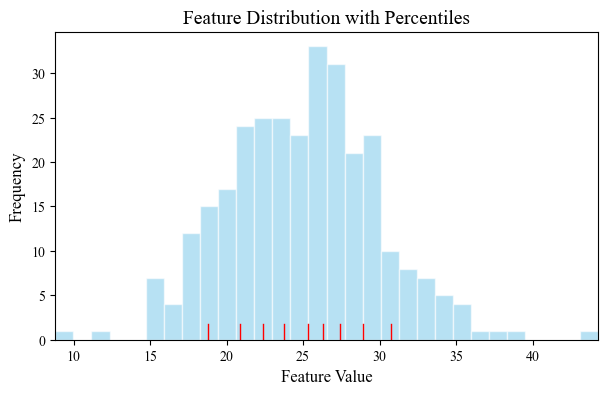

: 

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 假设我们有一个特征 X_feature（例如城市温度）
np.random.seed(42)
X_feature = np.random.normal(loc=25, scale=5, size=300)  # 正态分布模拟特征值

# 画布与直方图
plt.figure(figsize=(7,4))
plt.hist(X_feature, bins=30, color='skyblue', alpha=0.6, edgecolor='white')
plt.xlabel("Feature Value", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Feature Distribution with Percentiles", fontsize=14)

# === 你给的核心三行 ===
ax = plt.gca()
percentiles = np.percentile(X_feature, np.linspace(10, 90, 9))
rug_height = 0.05
# 在 X 轴画百分位位置的 rug plot（地毯线）
for p in percentiles:
    ax.plot([p, p], [0, rug_height * ax.get_ylim()[1]], color='red', lw=1)

plt.xlim(X_feature.min(), X_feature.max())
 
x_ticks[-1] = X_feature.max()   # 替换最后一个为最大值

plt.show()

# ext+nor self

In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2016]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\final_GBDT_summary_results.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdem = rf'{grid_folder}\statistics\SDM_SDEM_all_params.xlsx'
    best_df_sdem = pd.read_excel(best_params_file_sdem)
    best_df_sdem = best_df_sdem[best_df_sdem['Model']=='SDEM']

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    print(target_folder)

    for target in target_folder[1:]:

        # 先收集 EXT 和 NOR 的预测数据
        ext_targets = [t for t in target_folder if ('ext' in t.lower()) or ('nor' in t.lower())]
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- EXT + NOR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            for target in ext_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])

                # ----------- PDP 计算部分 -----------
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns)
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)

                # SDEM
                row_sdem = best_df_sdem[best_df_sdem['Target']==target].iloc[0]
                params_sdem = {
                    'CONSTANT': row_sdem['CONSTANT'],
                    'BCR': row_sdem['BCR'],
                    'BHV': row_sdem['BHV'],
                    'SVF': row_sdem['SVF'],
                    'NDVI': row_sdem['NDVI'],
                    'EV': row_sdem['EV'],
                    'WR': row_sdem['WR'],
                    'Dist_W': row_sdem['Dist_W'],
                    'Dist_P': row_sdem['Dist_P'],
                    'Dist_M': row_sdem['Dist_M'],
                    'W_BCR': row_sdem['W_BCR'],
                    'W_BHV': row_sdem['W_BHV'],
                    'W_SVF': row_sdem['W_SVF'],
                    'W_NDVI': row_sdem['W_NDVI'],
                    'W_EV': row_sdem['W_EV'],
                    'W_WR': row_sdem['W_WR'],
                    'lambda': row_sdem['lambda']
                }
                # SDEM 预测
                X_mean = gdf_clean[explanatory_vars].mean().to_dict()
                w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
                w.transform = 'r'
                WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values)
                WX_mean = pd.Series(WX.mean(axis=0), index=[f"W_{v}" for v in explanatory_vars_clean])
                y_sdem_pred = []
                for val in X_grid:
                    X_temp = X_mean.copy()
                    X_temp[feature] = val
                    WX_temp = WX_mean.copy()
                    if feature in explanatory_vars_clean:
                        WX_temp[feature] = pd.Series(val, index=[f"W_{feature}"])

                    all_vars = {'CONSTANT': 1.0, **X_temp, **WX_temp.to_dict()}
                    y_pred = 0
                    for var, coef in params_sdem.items():
                        if var != 'lambda':
                            y_pred += coef * all_vars.get(var, 0)
                    y_sdem_pred.append(y_pred)
                    
                y_sdem_pred = np.array(y_sdem_pred)

                # 根据 EXT/NOR 指定颜色
                if 'ext' in target.lower():
                    color_gbdt = '#333333'  # 黑色
                    color_sdem = '#555555'  # 黑色虚线
                else:  # NOR
                    color_gbdt = '#0000ff'  # 蓝色
                    color_sdem = '#0000ff'  # 蓝色虚线

                # 命名规范映射
                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名

                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdem_pred, color=color_sdm, linestyle='--', linewidth=2, label=f'{label_name} SDEM')

            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())

            # 设置全局字体为 Times New Roman
            plt.rcParams["font.family"] = "Times New Roman"

            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.margins(x=0)  # 去掉x方向留白
             
             
             
            plt.ylim(20, 55)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_ext_nor_{year}_comparison.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_ext_nor_{year}_comparison.png")

['nor_2016' 'ext_2016' 'hr_2016']


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved BCR_ext_nor_2016_comparison.png


...

('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
✅ Saved Dist_M_ext_nor_2016_comparison.png


: 

: 

# CV Pairs

In [ ]:
from sklearn.model_selection import train_test_split
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay

# ----------------- 配置 -----------------
grid_folder = r'E:\seoul\480_based'
output_fig_dir = os.path.join(grid_folder, 'Machine Learning', 'figures', 'pdp_direct_plot')
os.makedirs(output_fig_dir, exist_ok=True)


explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
years = [2016]
top_n_features = 9  # PDP 提取 top N 变量

# ----------------- 主循环 -----------------
for year in years:
    file = fr'E:\seoul\480_based\city{year}_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file)

    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\cv_pairs.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)

    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)

    # --- 目标变量分组 ---
    targets = 'hr_2016'

    for feature in explanatory_vars:
        # 建一张图
        fig, ax = plt.subplots(figsize=(8,5))

        for seed in range(20):
            row_gbdt = best_df_gbdt[best_df_gbdt['Seed'] == seed].iloc[0]
            params_gbdt = {
                'learning_rate': row_gbdt['learning_rate'],
                'max_depth': int(row_gbdt['max_depth']),
                'n_estimators': 4168,
                'subsample': row_gbdt['subsample'],
                'min_samples_split': 2,
                'max_features': float(row_gbdt['max_features']),
                'random_state': 0
            }

            X = gdf_clean[explanatory_vars_gbdt]
            y = gdf_clean[targets]   # 注意这里应该是 targets 而不是 target
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2,
                random_state=int(str(row_gbdt["prefix"]).split("_")[1])
            )
            model = GradientBoostingRegressor(**params_gbdt).fit(X_train, y_train)

            # ----------- PDP 计算部分 -----------

            X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
            X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns)
            X_base[feature] = X_grid

            y_gbdt_pred = model.predict(X_base)

            if seed == 0:
                for x in X[feature]:
                    plt.axvline(x=x, color='gray', alpha=0.1, linewidth=0.1)
            if seed == 9:
                ax.plot(X_grid, y_gbdt_pred, linewidth=2.5, color="red",
                        label="The final nonlinear curve", zorder=10)
            else:
                ax.plot(X_grid, y_gbdt_pred, linewidth=1, color="gray", alpha=0.5, zorder=1)

        # 设置全局字体为 Times New Roman
        plt.rcParams["font.family"] = "Times New Roman"
        plt.xlabel(feature, fontsize=16)
        plt.ylabel('Temperature (℃)', fontsize=16)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.grid(False)
        ax.legend(loc='upper right', frameon=False, fontsize=12)
        ax.set_ylim(-15, 1)
        plt.tight_layout()
        fig.savefig(os.path.join(output_dir, f'Seed_PDP_{feature}_hr.jpg'), dpi=300)
        plt.close(fig)


: 

: 